In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

df = pd.read_csv("titanic.csv")
df.head()

,PassengerId,Name,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,1,"Braund, Mr. Owen Harris",3,male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,"Heikkinen, Miss. Laina",3,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,female,35.0,1,0,113803,53.1000,C123,S,1
4,5,"Allen, Mr. William Henry",3,male,35.0,0,0,373450,8.0500,NaN,S,0


In [2]:
df = df.drop(["PassengerId", "Name", "Ticket"], axis=1)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Sex       891 non-null    object 
 2   Age       714 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
 6   Cabin     204 non-null    object 
 7   Embarked  889 non-null    object 
 8   Survived  891 non-null    int64  
dtypes: float64(2), int64(4), object(3)
memory usage: 62.8+ KB


In [4]:
df.isnull().sum()

Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
Survived      0
dtype: int64

In [5]:
df["Embarked"].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [6]:
len(df["Cabin"].unique())

148

In [7]:
df["Sex"].unique()

array(['male', 'female'], dtype=object)

In [8]:
features_with_na = [feature for feature in df.columns if df[feature].isnull().sum() > 1 and df[feature].dtypes=='O']

for feature in features_with_na :
    print(feature, np.round(df[feature].isnull().mean(),4), "% missing values")

Cabin 0.771 % missing values
Embarked 0.0022 % missing values


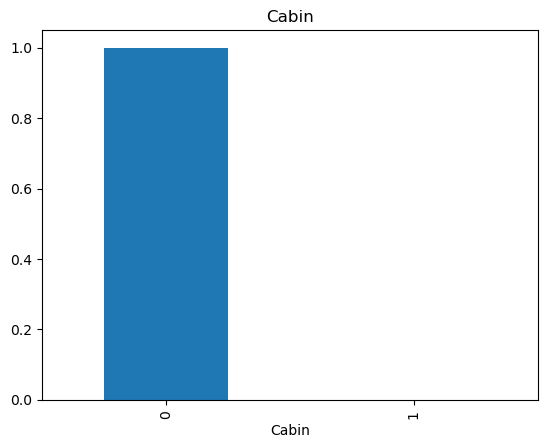

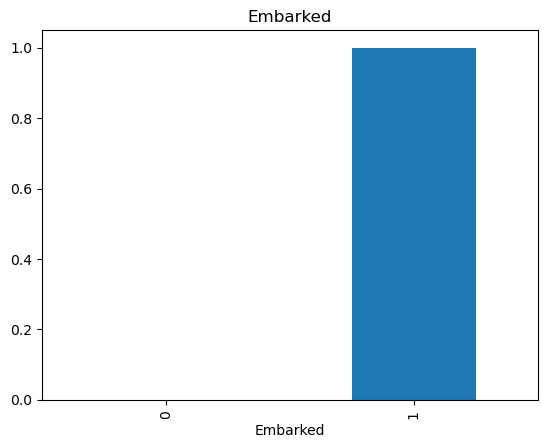

In [9]:
for feature in features_with_na: 
    data = df.copy()
    
    # indicates 1 if the observation was missing or zero otherwise
    data[feature] = np.where(data[feature].isnull(), 1,0)

    # mean of the SalePrice where the information is missing or present 
    data.groupby(feature)["Survived"].median().plot.bar()
    plt.title(feature)
    plt.show()

nan verilerin etkisi var, yeni kategori oluşturulacak 
age için belki mean ile doldurulabilir 

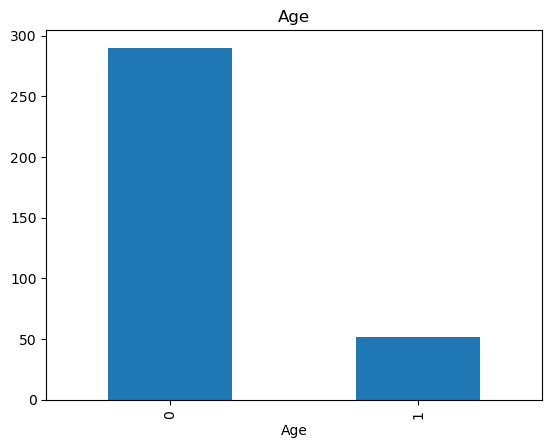

In [11]:
data = df.copy()
    
    # indicates 1 if the observation was missing or zero otherwise
data["Age"] = np.where(data["Age"].isnull(), 1,0)

    # mean of the SalePrice where the information is missing or present 
data.groupby("Age")["Survived"].sum().plot.bar()
plt.title("Age")
plt.show()

In [12]:
numerical_features = [feature for feature in df.columns if df[feature].dtypes != "O"]
df[numerical_features].head()

,Pclass,Age,SibSp,Parch,Fare,Survived
0,3,22.0,1,0,7.2500,0
1,1,38.0,1,0,71.2833,1
2,3,26.0,0,0,7.9250,1
3,1,35.0,1,0,53.1000,1
4,3,35.0,0,0,8.0500,0


In [13]:
discrete_features = [feature for feature in numerical_features if len(df[feature].unique())<25]
discrete_features.remove("Survived")
discrete_features

['Pclass', 'SibSp', 'Parch']

In [14]:
continuous_features = [feature for feature in numerical_features if feature not in discrete_features]
continuous_features.remove("Survived")
continuous_features

['Age', 'Fare']

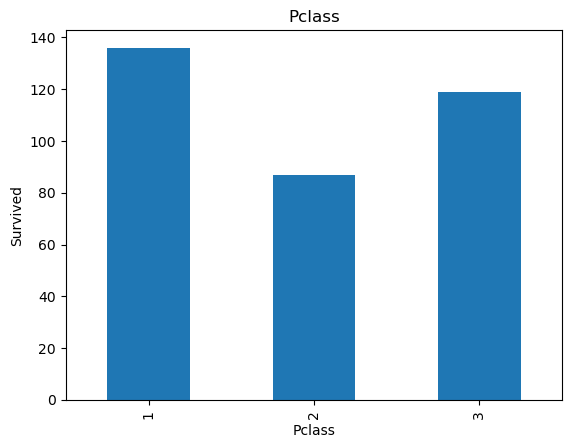

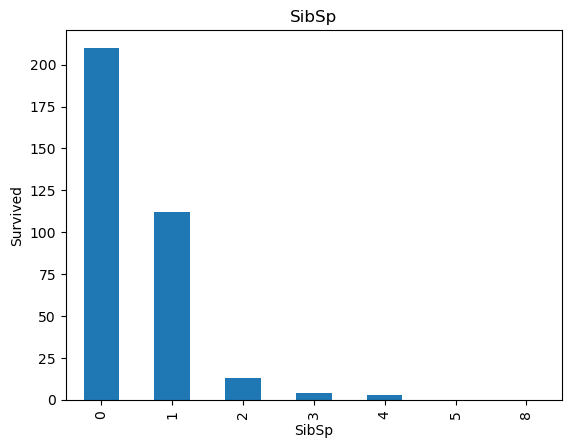

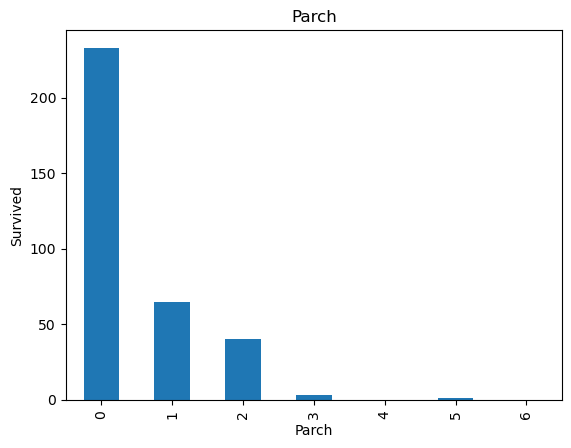

In [15]:
for feature in discrete_features:
    data = df.copy()
    data.groupby(feature)["Survived"].sum().plot.bar()
    plt.xlabel(feature)
    plt.ylabel("Survived")
    plt.title(feature)
    plt.show()

Pclass ile survived alakalı görünmüyor, diğerleri ile ilişki var 

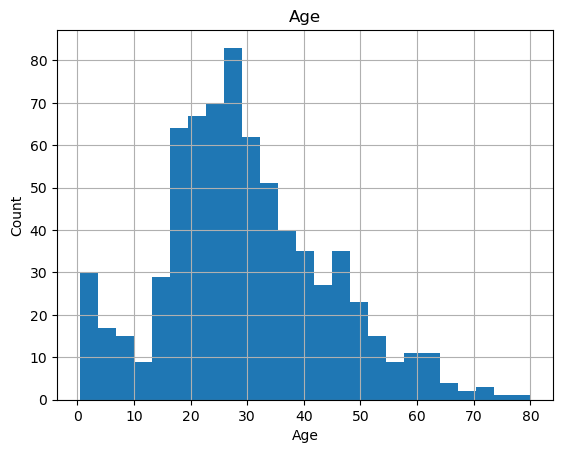

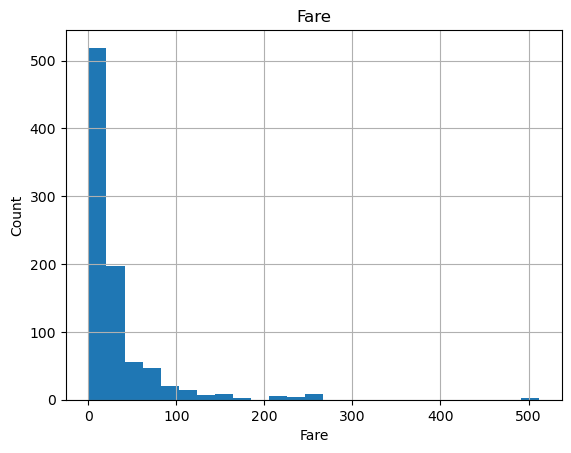

In [17]:
for feature in continuous_features:
    data=df.copy()
    data[feature].hist(bins=25)
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.title(feature)
    plt.show()

her ikisi de skewed, ona göre log transform ya da başka bir işlem 

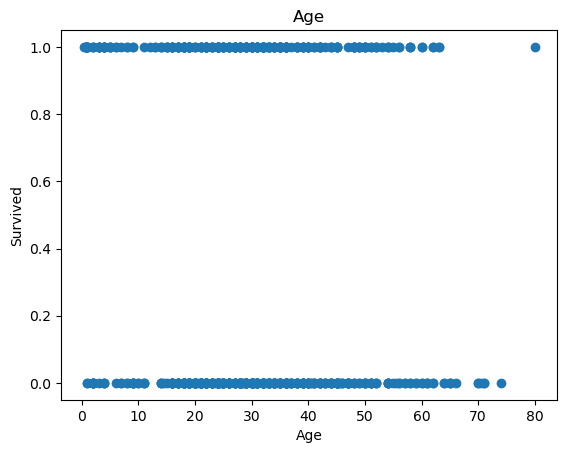

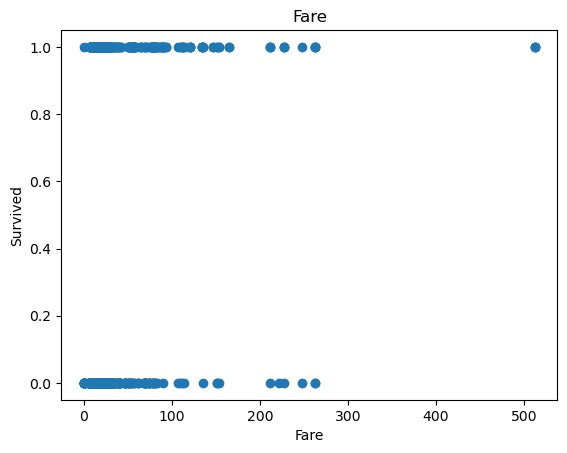

In [19]:
for feature in continuous_features:
    data = df.copy()

    # data[feature] = np.log1p(data[feature])
    # data["Survived"] = np.log1p(data["Survived"])
    plt.scatter(data[feature], data["Survived"])
    plt.xlabel(feature)
    plt.ylabel("Survived")
    plt.title(feature)
    plt.show()

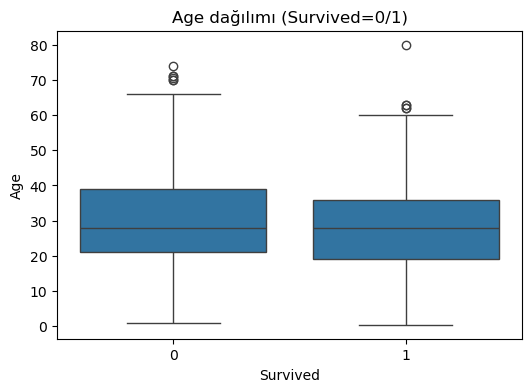

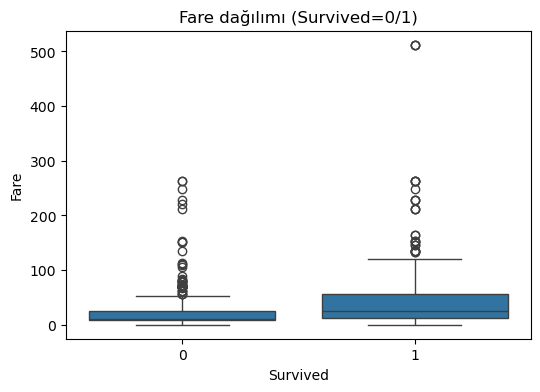

                Age       Fare
Survived                      
0         30.626179  22.117887
1         28.343690  48.395408


In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Age vs Survived boxplot
plt.figure(figsize=(6,4))
sns.boxplot(x="Survived", y="Age", data=df)
plt.title("Age dağılımı (Survived=0/1)")
plt.show()

# Fare vs Survived boxplot
plt.figure(figsize=(6,4))
sns.boxplot(x="Survived", y="Fare", data=df)
plt.title("Fare dağılımı (Survived=0/1)")
plt.show()

# Ortalama değerleri görmek için
print(df.groupby("Survived")[["Age","Fare"]].mean())


## Outliers

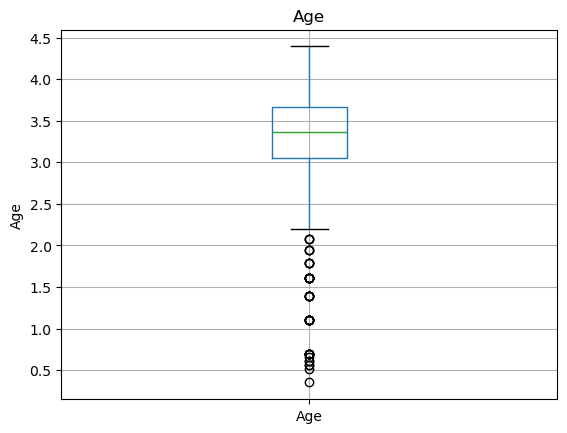

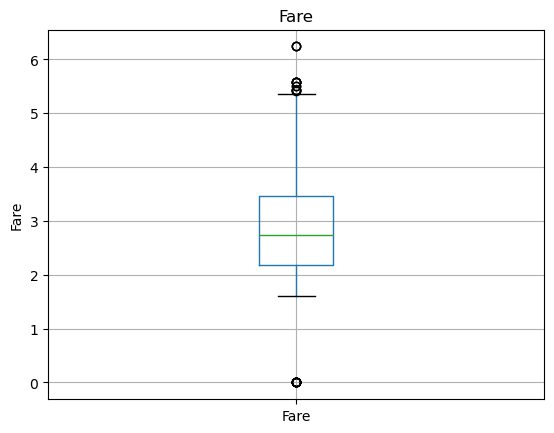

In [22]:
for feature in continuous_features:
    data = df.copy()
     
    data[feature] = np.log1p(data[feature])
    data.boxplot(column=feature)
    plt.ylabel(feature)
    plt.title(feature)
    plt.show()

In [23]:
categorical_features = [feature for feature in df.columns if data[feature].dtypes=="O"]
categorical_features

['Sex', 'Cabin', 'Embarked']

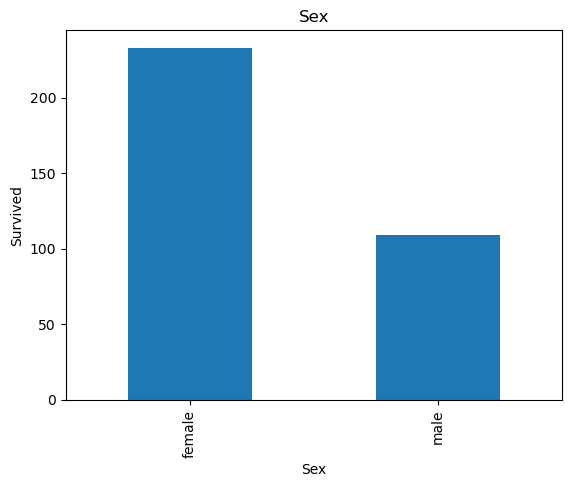

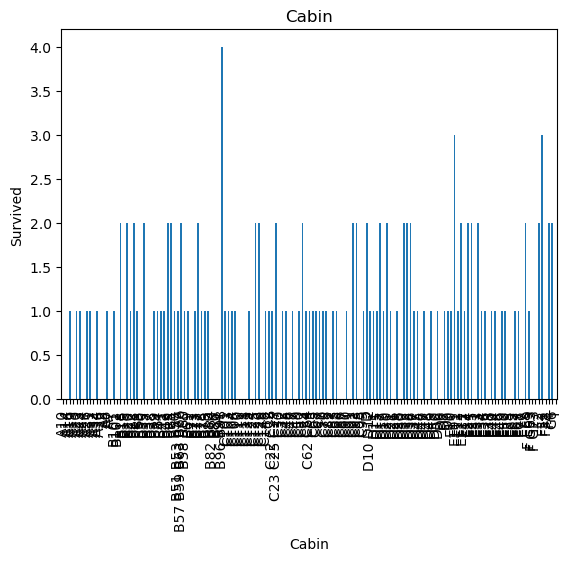

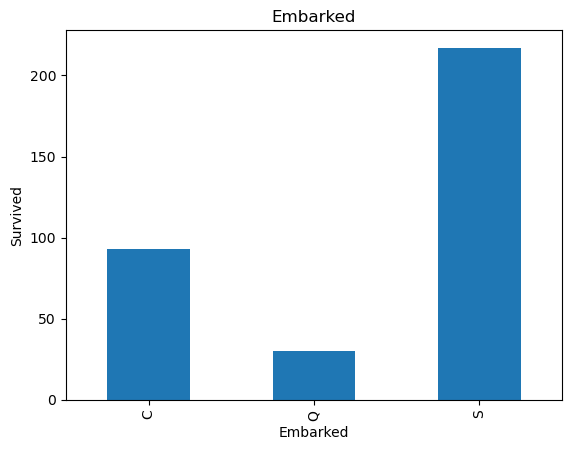

In [24]:
for feature in categorical_features:
    data = df.copy()
    data.groupby(feature)["Survived"].sum().plot.bar()
    plt.xlabel(feature)
    plt.ylabel("Survived")
    plt.title(feature)
    plt.show()

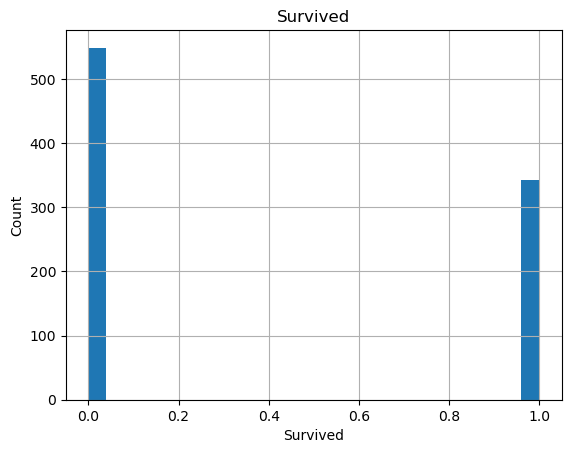

In [25]:
data=df.copy()
data["Survived"].hist(bins=25)
plt.xlabel("Survived")
plt.ylabel("Count")
plt.title("Survived")
plt.show()

In [26]:
features_with_na

['Cabin', 'Embarked']

In [27]:

median_value = df["Age"].median()
df["Age"] = df["Age"].fillna(median_value)
df.isnull().sum()

Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
Survived      0
dtype: int64

In [28]:
for feature in features_with_na: 
    df[feature + "nan"] = np.where(df[feature].isnull(), 1, 0)
df[features_with_na].isnull().sum()

Cabin       687
Embarked      2
dtype: int64

In [29]:
# replacing categorical missing values 
def replace_cat_features(dataset, features_with_na):
    data = dataset.copy()
    data[features_with_na] = data[features_with_na].fillna("Missing")
    return data 

df = replace_cat_features(df, features_with_na)
df[features_with_na].isnull().sum()

Cabin       0
Embarked    0
dtype: int64

In [30]:
categorical_features

['Sex', 'Cabin', 'Embarked']

In [31]:

df.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Survived,Cabinnan,Embarkednan
0,3,male,22.0,1,0,7.2500,Missing,S,0,1,0
1,1,female,38.0,1,0,71.2833,C85,C,1,0,0
2,3,female,26.0,0,0,7.9250,Missing,S,1,1,0
3,1,female,35.0,1,0,53.1000,C123,S,1,0,0
4,3,male,35.0,0,0,8.0500,Missing,S,0,1,0


In [32]:
for feature in categorical_features: 
    labels_ordered = df.groupby([feature])["Survived"].mean().sort_values().index
    labels_ordered = {k:i for i,k in enumerate(labels_ordered, 0)}
    df[feature] = df[feature].map(labels_ordered)
df.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Survived,Cabinnan,Embarkednan
0,3,0,22.0,1,0,7.2500,46,0,0,1,0
1,1,1,38.0,1,0,71.2833,124,2,1,0,0
2,3,1,26.0,0,0,7.9250,46,0,1,1,0
3,1,1,35.0,1,0,53.1000,48,0,1,0,0
4,3,0,35.0,0,0,8.0500,46,0,0,1,0


In [33]:
discrete_features

['Pclass', 'SibSp', 'Parch']

In [34]:
df['Family_size']=df['SibSp'] + df['Parch'] + 1

In [35]:
df.drop(["SibSp", "Parch"], axis=1, inplace=True)

In [36]:
df.head()

,Pclass,Sex,Age,Fare,Cabin,Embarked,Survived,Cabinnan,Embarkednan,Family_size
0,3,0,22.0,7.2500,46,0,0,1,0,2
1,1,1,38.0,71.2833,124,2,1,0,0,2
2,3,1,26.0,7.9250,46,0,1,1,0,1
3,1,1,35.0,53.1000,48,0,1,0,0,2
4,3,0,35.0,8.0500,46,0,0,1,0,1


In [37]:
def family_size(number):
    if number==1:
        return 1
    elif number>1 and number <5:
        return 2
    else:
        return 3

df['Family_size']=df['Family_size'].apply(family_size)

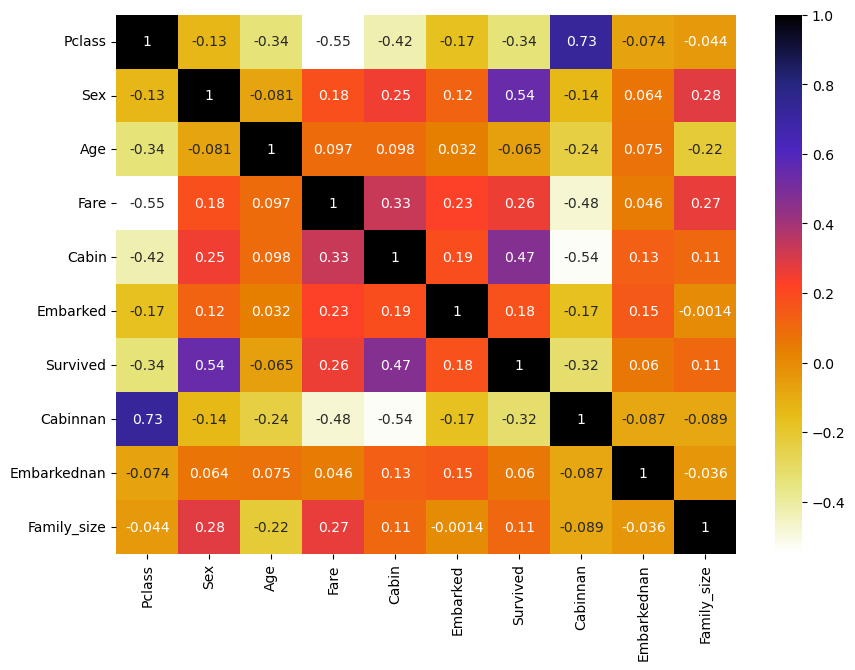

In [38]:
import seaborn as sns 
plt.figure(figsize=(10,7))
cor = df.corr()
sns.heatmap(cor, annot=True , cmap=plt.cm.CMRmap_r)
plt.show()

In [39]:
col=['Embarked','Pclass','Sex','Family_size']
for i in col:
    print('Survival Correlation by:', i)
    df2=df.groupby(i)['Survived'].mean().reset_index()
    print(df2)
    print('-'*10, '\n')

Survival Correlation by: Embarked
   Embarked  Survived
0         0  0.336957
1         1  0.389610
2         2  0.553571
3         3  1.000000
---------- 

Survival Correlation by: Pclass
   Pclass  Survived
0       1  0.629630
1       2  0.472826
2       3  0.242363
---------- 

Survival Correlation by: Sex
   Sex  Survived
0    0  0.188908
1    1  0.742038
---------- 

Survival Correlation by: Family_size
   Family_size  Survived
0            1  0.303538
1            2  0.578767
2            3  0.161290
---------- 



In [40]:
X = df.drop(labels=["Survived"], axis=1)
y = df["Survived"]

from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [41]:
from sklearn.feature_selection import VarianceThreshold
var_thres = VarianceThreshold(threshold=0)
var_thres.fit(X_train)

VarianceThreshold(threshold=0)

In [42]:
constant_columns = [column for column in X_train.columns
                   if column not in X_train.columns[var_thres.get_support()]]
constant_columns

[]

In [43]:
from sklearn.feature_selection import mutual_info_classif
mutual_info = mutual_info_classif(X_train, y_train)
mutual_info

array([0.04520864, 0.1669256 , 0.03287403, 0.09617497, 0.1547773 ,
       0.03591199, 0.0415249 , 0.        , 0.03366484])

In [44]:
mutual_info = pd.Series(mutual_info)
mutual_info.index = X_train.columns
mutual_info.sort_values(ascending=False)

Sex            0.166926
Cabin          0.154777
Fare           0.096175
Pclass         0.045209
Cabinnan       0.041525
Embarked       0.035912
Family_size    0.033665
Age            0.032874
Embarkednan    0.000000
dtype: float64

In [45]:
df.drop(["Embarkednan"], axis=1, inplace=True)

In [46]:
df[categorical_features].head()

,Sex,Cabin,Embarked
0,0,46,0
1,1,124,2
2,1,46,0
3,1,48,0
4,0,46,0


In [47]:
from sklearn.feature_selection import chi2
f_p_values = chi2(X_train[categorical_features], y_train)
f_p_values

(array([ 116.30072353, 1196.88512915,   31.11277991]),
 array([4.08423235e-027, 2.89899988e-262, 2.43463167e-008]))

In [48]:
import pandas as pd
p_values = pd.Series(f_p_values[1])
p_values.index = X_train[categorical_features].columns
p_values.sort_index(ascending=False)

Sex          4.084232e-27
Embarked     2.434632e-08
Cabin       2.899000e-262
dtype: float64

In [49]:
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier(criterion="entropy")
dtc.fit(X_train, y_train)
y_pred = dtc.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
cm

array([[70, 17],
       [10, 37]], dtype=int64)

In [50]:
# from sklearn.feature_selection import SelectFromModel
# from sklearn.ensemble import RandomForestClassifier

# selector = SelectFromModel(estimator=RandomForestClassifier(), threshold="median").fit(X_train, y_train)
# selector.get_support()
# col = [col for col in X_train.columns if col not in X_train.columns[selector.get_support()]]
# col

In [51]:
# X_train.drop(col, axis=1, inplace=True)
# X_test.drop(col, axis=1, inplace=True)
# X_train.head()

In [52]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
cm

array([[73, 14],
       [12, 35]], dtype=int64)

In [53]:
clf.score(X_test, y_test)

0.8059701492537313

In [54]:
from sklearn.ensemble import BaggingClassifier

bag_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100, 
    max_samples=0.8,
    oob_score=True,
    random_state=0
)
bag_model.fit(X_train, y_train)
bag_model.oob_score_

0.8635634028892456

In [55]:
bag_model.score(X_test, y_test)

0.835820895522388

In [56]:
from sklearn.tree import DecisionTreeClassifier 
from sklearn.model_selection import cross_val_score

scores = cross_val_score(DecisionTreeClassifier(), X_train, y_train, cv=5)
scores

array([0.784     , 0.8       , 0.808     , 0.83870968, 0.83064516])

In [57]:
from sklearn.ensemble import AdaBoostClassifier
ada = AdaBoostClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=0)
ada.fit(X_train, y_train)
ada.score(X_test, y_test)

C:\Users\atahi\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


0.8059701492537313

In [58]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import ShuffleSplit 
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeRegressor

def find_best_model_using_gridsearchcv(X,y):
    algos = {
    
        'decision_tree': {
            'model': DecisionTreeClassifier(),
            'params': {
                'criterion' : ['gini', 'entropy', 'log_loss'],
                'splitter': ['best','random']
            }
        }
    }
    scores = []
    cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
    for algo_name, config in algos.items():
        gs =  GridSearchCV(config['model'], config['params'], cv=cv, return_train_score=False)
        gs.fit(X,y)
        scores.append({
            'model': algo_name,
            'best_score': gs.best_score_,
            'best_params': gs.best_params_
        })

    return pd.DataFrame(scores,columns=['model','best_score','best_params'])

find_best_model_using_gridsearchcv(X_valid, y_valid)

,model,best_score,best_params
0,decision_tree,0.903704,"{'criterion': 'entropy', 'splitter': 'random'}"


In [59]:
grid = GridSearchCV(DecisionTreeClassifier(), {
    'criterion' : ['gini', 'entropy', 'log_loss'],
    'splitter': ['best','random']
}, cv=5, return_train_score=False)

grid.fit(X_valid, y_valid)
pd.DataFrame(grid.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_splitter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.004587,0.002234,0.003183,0.001164,gini,best,"{'criterion': 'gini', 'splitter': 'best'}",0.814815,0.777778,0.888889,0.814815,0.923077,0.843875,0.053585,1
1,0.002401,0.000484,0.001803,0.000404,gini,random,"{'criterion': 'gini', 'splitter': 'random'}",0.777778,0.740741,0.888889,0.703704,0.961538,0.814530,0.096144,4
2,0.002194,0.000399,0.000997,0.000001,entropy,best,"{'criterion': 'entropy', 'splitter': 'best'}",0.777778,0.851852,0.888889,0.814815,0.846154,0.835897,0.037390,2
3,0.002188,0.000403,0.001801,0.000402,entropy,random,"{'criterion': 'entropy', 'splitter': 'random'}",0.740741,0.666667,0.962963,0.740741,0.884615,0.799145,0.108180,5
4,0.002785,0.000396,0.001996,0.000001,log_loss,best,"{'criterion': 'log_loss', 'splitter': 'best'}",0.777778,0.851852,0.888889,0.814815,0.846154,0.835897,0.037390,2
5,0.002793,0.000726,0.001994,0.000631,log_loss,random,"{'criterion': 'log_loss', 'splitter': 'random'}",0.740741,0.740741,0.851852,0.666667,0.884615,0.776923,0.079983,6


In [60]:
best_model = DecisionTreeClassifier(criterion='log_loss', splitter='random')
best_model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='log_loss', splitter='random')

In [61]:
best_model.score(X_test, y_test)

0.8208955223880597